/var/folders/_y/g1xzvf1d20q8wdsh4z4jlrdh0000gn/T/ipykernel_95643/3565971381.py:153: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=violin_data,


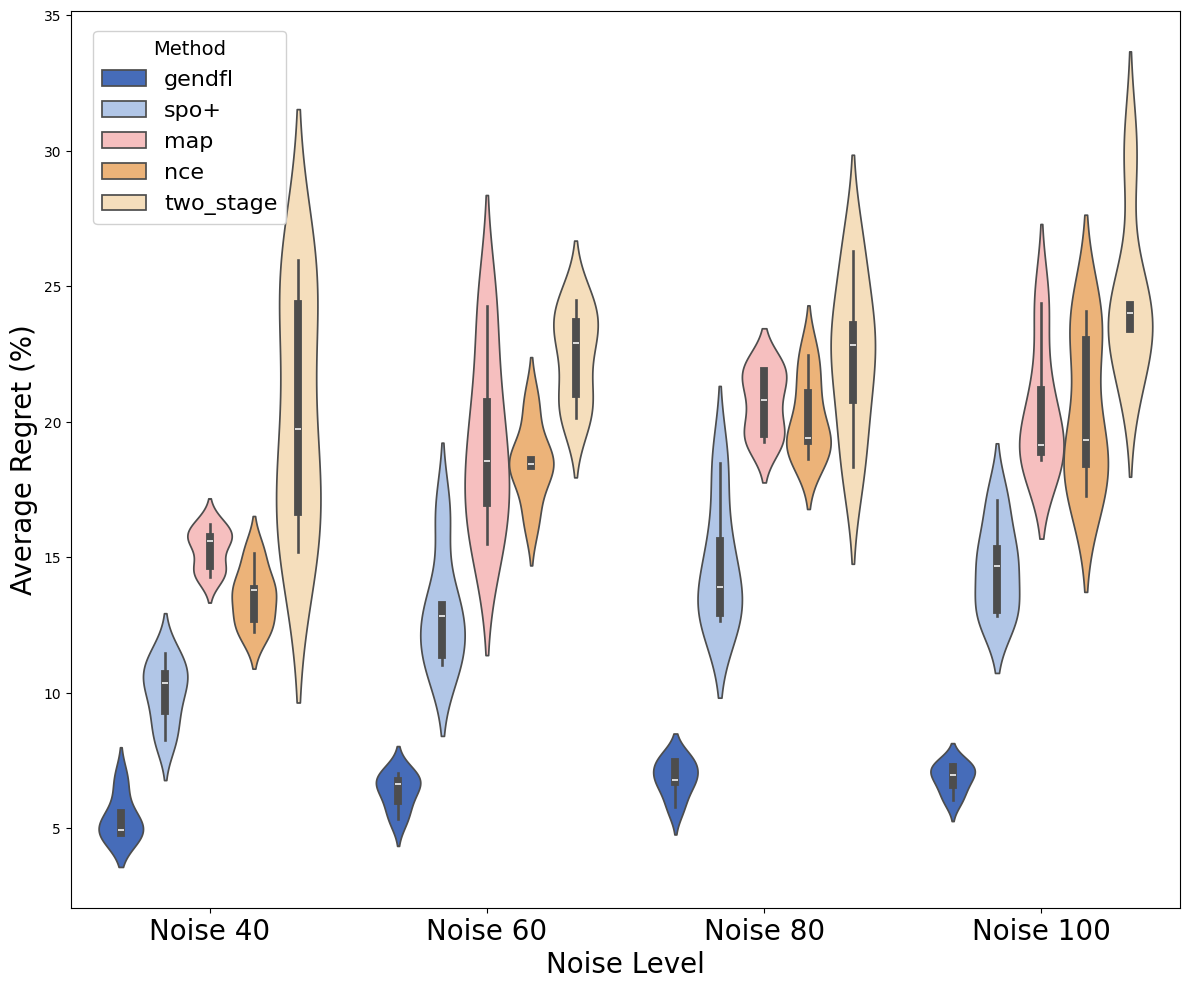

In [27]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt




def load_noise():
    # methods = ['spo+', 'lltr', 'pltr', 'ptltr', 'map', 'two_stage', 'nce']
    methods = ['spo+', 'map', 'nce', 'two_stage']
    noises = [40, 60, 80, 100]
    all_data = []
    
    # Read each file (different training alphas)
    for noise in noises:
        filename = f'all_results_end2end_betas100.0_alpha_1.0_m50_noise_{noise}.json'
       
        with open(filename, 'r') as f:
            data = json.load(f)
        
        # Process each experiment
        df = pd.DataFrame(data)
        
        # Get all regret values, not just the mean
        deg_data = df[df['deg'] == 4]
        for _, row in deg_data.iterrows():
            row_data = {
                'method': 'gendfl',
                'noise': noise,
                'average_regret': row['average_regret'],
            }
            all_data.append(row_data)

    for method in methods:
        for noise in noises:
            for i in range(5):
                filename = f'pred_{method}/pred_results_deg4_exp_{i}_m50_n400_noise_{noise}.json'
                with open(filename, 'r') as f:
                    data = json.load(f)
                df = pd.DataFrame(data)
                # Get all regret values, not just the mean
                deg_data = df[df['deg'] == 4]
                for _, row in deg_data.iterrows():
                    row_data = {
                        'method': method,
                        'noise': noise,
                        'average_regret': row['average_regret'],
                    }
                    all_data.append(row_data)

    return pd.DataFrame(all_data)

def load_d():
    # methods = ['spo+', 'lltr', 'pltr', 'ptltr', 'map', 'two_stage', 'nce']
    methods = ['spo+', 'map', 'nce', 'two_stage']
    ds = [100, 150, 200]
    all_data = []
    
    # Read each file (different training alphas)
    for d in ds:
        for i in range(5):
            filename = f'beta_100.0_alpha_1.0/end2end_cflowdfl_results_exp_{i}_m{d}_n400_noise_{d}.json'
       
            with open(filename, 'r') as f:
                data = json.load(f)
            
            # Process each experiment
            df = pd.DataFrame(data)
            
            # Get all regret values, not just the mean
            deg_data = df[df['deg'] == 5]
            for _, row in deg_data.iterrows():
                row_data = {
                    'method': 'gendfl',
                    'd': d,
                    'average_regret': row['average_regret'],
                }
                all_data.append(row_data)

    for method in methods:
        for d in ds:
            filename = f'pred_{method}/pred_results_deg5_m{d}_n400_noise_{d}.json'
            with open(filename, 'r') as f:
                data = json.load(f)
            df = pd.DataFrame(data)
            # Get all regret values, not just the mean
            deg_data = df[df['deg'] == 5]
            for _, row in deg_data.iterrows():
                row_data = {
                    'method': method,
                    'd': d,
                    'average_regret': row['average_regret'],
                }
                all_data.append(row_data)

    return pd.DataFrame(all_data)

def load_n():
    # methods = ['spo+', 'lltr', 'pltr', 'ptltr', 'map', 'two_stage', 'nce']
    methods = ['spo+', 'map', 'nce', 'two_stage']
    ns = [200,400, 800]
    all_data = []
    
    # Read each file (different training alphas)
    for n in ns:
        filename = f'all_results_end2end_deg5_betas100.0_alpha_1.0_m50_noise_20_n{n}.json'
    
        with open(filename, 'r') as f:
            data = json.load(f)
        
        # Process each experiment
        df = pd.DataFrame(data)
        
        # Get all regret values, not just the mean
        deg_data = df[df['deg'] == 5]
        for _, row in deg_data.iterrows():
            row_data = {
                'method': 'gendfl',
                'n': n,
                'average_regret': row['average_regret'],
            }
            all_data.append(row_data)

    for method in methods:
        for n in ns:
            filename = f'pred_{method}/pred_results_deg5_m50_n{n}_noise_20.json'
            with open(filename, 'r') as f:
                data = json.load(f)
            df = pd.DataFrame(data)
            # Get all regret values, not just the mean
            deg_data = df[df['deg'] == 5]
            for _, row in deg_data.iterrows():
                row_data = {
                    'method': method,
                    'n': n,
                    'average_regret': row['average_regret'],
                }
                all_data.append(row_data)

    return pd.DataFrame(all_data)


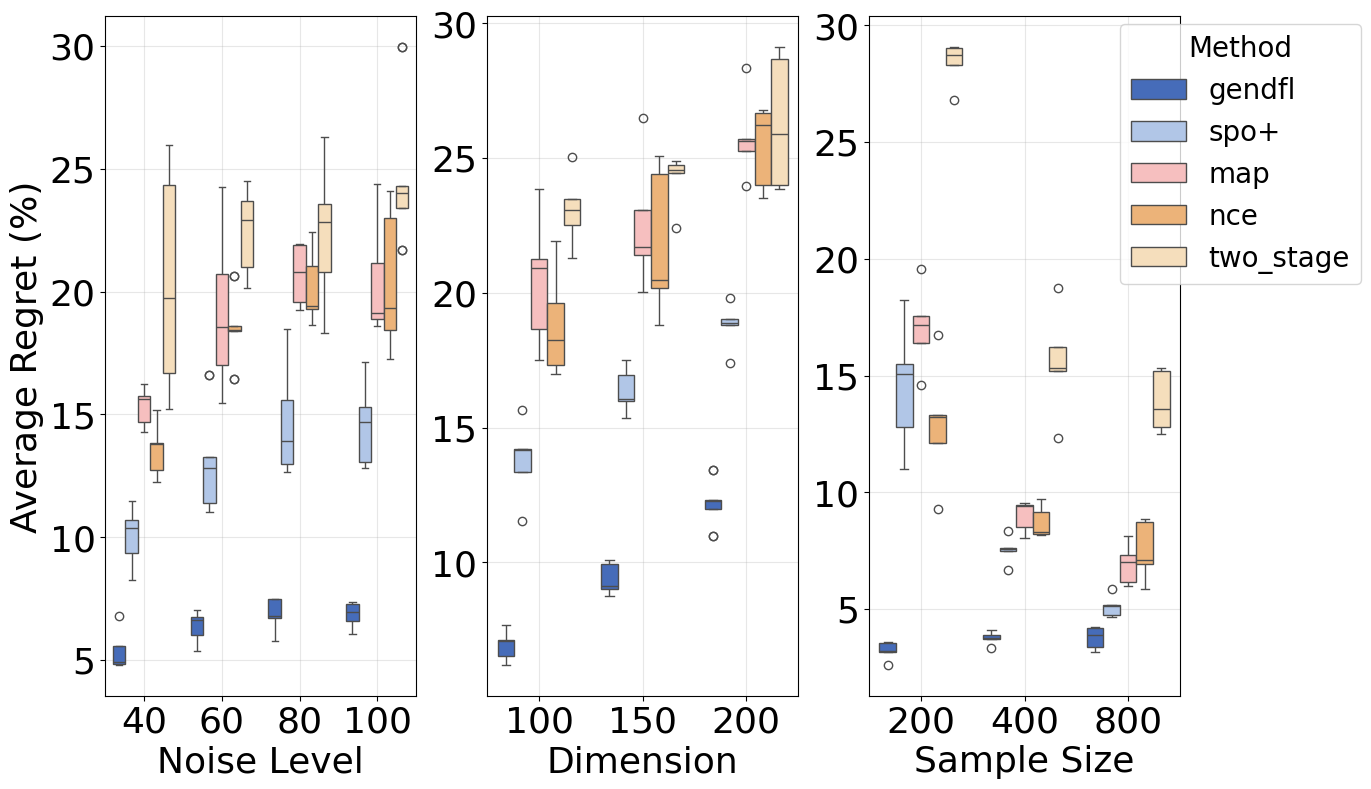

In [31]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

colors = {
    'gendfl': '#3366CC',      # Keep original deep blue for gendfl
    'nce': '#FFB366',         # Light blue
    'spo+': '#A8C4F0',        # Light orange
    'map': '#FFB6B6',         # Light red
    'two_stage': '#FFE0B2'    # Light peach
}


# Create a figure with three subplots in a row
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 8))

# First subplot - Noise
noise_data = load_noise()
noise_data_plot = noise_data.copy()
noise_data_plot['noise'] = noise_data_plot['noise'].apply(lambda x: f'{x}')
noise_data_plot['average_regret'] = noise_data_plot['average_regret'] * 100

sns.boxplot(data=noise_data_plot,
            x='noise',
            y='average_regret',
            hue='method',
            palette=colors,
            ax=ax1)

ax1.set_xlabel('Noise Level', fontsize=26)
ax1.set_ylabel('Average Regret (%)', fontsize=26)
ax1.tick_params(axis='both', which='major', labelsize=26)
ax1.grid(True, alpha=0.3)
ax1.get_legend().remove()  # Remove individual legend

# Second subplot - Dimension
dim_data = load_d()
dim_data_plot = dim_data.copy()
dim_data_plot['d'] = dim_data_plot['d'].apply(lambda x: f'{x}')
dim_data_plot['average_regret'] = dim_data_plot['average_regret'] * 100

sns.boxplot(data=dim_data_plot,
            x='d',
            y='average_regret',
            hue='method',
            palette=colors,
            ax=ax2)

ax2.set_xlabel('Dimension', fontsize=26)
ax2.set_ylabel('', fontsize=26)  # Remove y-label for middle plot
ax2.tick_params(axis='both', which='major', labelsize=26)
ax2.grid(True, alpha=0.3)
ax2.get_legend().remove()  # Remove individual legend

# Third subplot - Sample size
n_data = load_n()
n_data_plot = n_data.copy()
n_data_plot['n'] = n_data_plot['n'].apply(lambda x: f'{x}')
n_data_plot['average_regret'] = n_data_plot['average_regret'] * 100

sns.boxplot(data=n_data_plot,
            x='n',
            y='average_regret',
            hue='method',
            palette=colors,
            ax=ax3)

ax3.set_xlabel('Sample Size', fontsize=26)
ax3.set_ylabel('', fontsize=26)  # Remove y-label for right plot
ax3.tick_params(axis='both', which='major', labelsize=26)
ax3.grid(True, alpha=0.3)

# Get the legend from the last plot and place it to the right of all subplots
handles, labels = ax3.get_legend_handles_labels()
fig.legend(handles, labels,
          title='Method',
          loc='center right',
          fontsize=20,
          title_fontsize=20,
          bbox_to_anchor=(1.15, 0.8))

ax3.get_legend().remove()  # Remove individual legend

plt.tight_layout()
plt.savefig('regret_comparison.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()